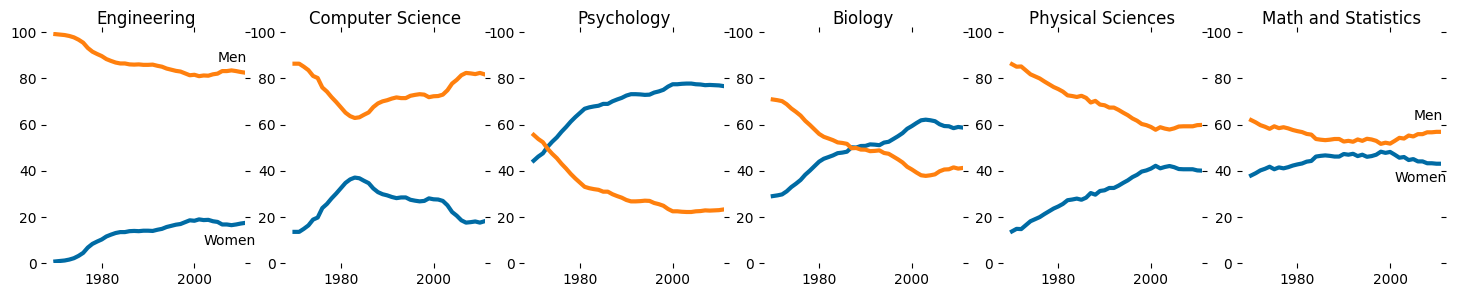

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

women_degrees = pd.read_csv('percent-bachelors-degrees-women-usa.csv')
cb_dark_blue = (0/255,107/255,164/255)
cb_orange = (255/255, 128/255, 14/255)
stem_cats = ['Engineering', 'Computer Science', 'Psychology', 'Biology', 'Physical Sciences', 'Math and Statistics']

fig = plt.figure(figsize=(18, 3))

for sp in range(0,6):
    ax = fig.add_subplot(1,6,sp+1)
    ax.plot(women_degrees['Year'], women_degrees[stem_cats[sp]], c=cb_dark_blue, label='Women', linewidth=3)
    ax.plot(women_degrees['Year'], 100-women_degrees[stem_cats[sp]], c=cb_orange, label='Men', linewidth=3)
    ax.spines["right"].set_visible(False)    
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)    
    ax.spines["bottom"].set_visible(False)
    ax.set_xlim(1968, 2011)
    ax.set_ylim(0,100)
    ax.set_title(stem_cats[sp])
    ax.tick_params(bottom="off", top="off", left="off", right="off")
    
    if sp == 0:
        ax.text(2005, 87, 'Men')
        ax.text(2002, 8, 'Women')
    elif sp == 5:
        ax.text(2005, 62, 'Men')
        ax.text(2001, 35, 'Women')
plt.show()

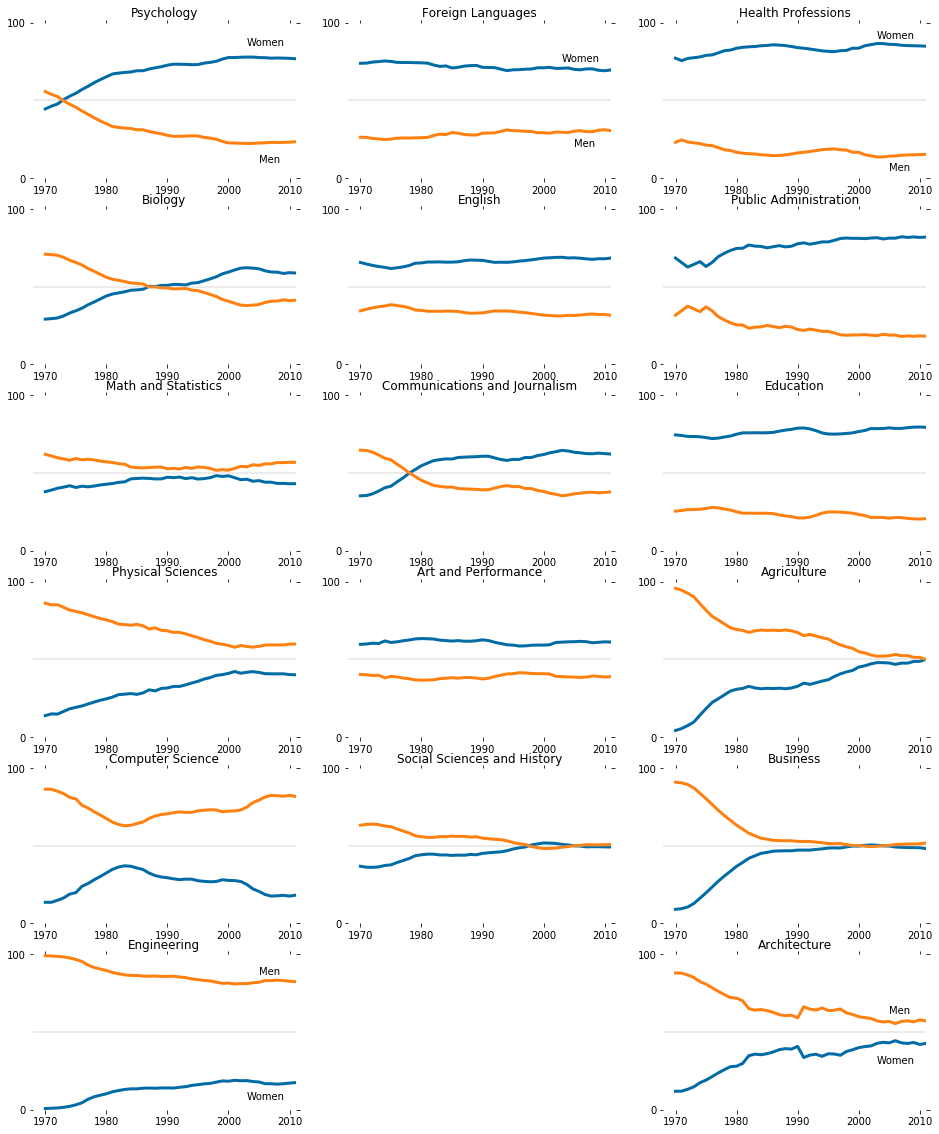

In [23]:
# There are 17 degrees that we need to process. We can group them based on STEM, Liberal Arts, or Others
stem_cats = ['Psychology', 'Biology', 'Math and Statistics', 'Physical Sciences', 'Computer Science', 'Engineering']
lib_arts_cats = ['Foreign Languages', 'English', 'Communications and Journalism', 'Art and Performance', 'Social Sciences and History']
other_cats = ['Health Professions', 'Public Administration', 'Education', 'Agriculture','Business', 'Architecture']

fig = plt.figure(figsize = (16, 20))

#First, we'll focus on the first column, and generate data for STEM

for sp in range(0,18,3):
    cat_index = int(sp/3)
    ax = fig.add_subplot(6,3,sp+1)
    ax.plot(women_degrees['Year'], women_degrees[stem_cats[cat_index]], c=cb_dark_blue, label='Women', linewidth=3)
    ax.plot(women_degrees['Year'], 100-women_degrees[stem_cats[cat_index]], c=cb_orange, label='Men', linewidth=3)
    for key,spine in ax.spines.items():
        spine.set_visible(False)
    ax.set_xlim(1968, 2011)
    ax.set_ylim(0,100)
    ax.set_title(stem_cats[cat_index])
    ax.tick_params(bottom="off", top="off", left="off", right="off")
    ax.axhline(50, c=(171/255, 171/255, 171/255), alpha=0.3)
    ax.set_yticks([0,100])
    
    if cat_index == 0:
        ax.text(2003, 85, 'Women')
        ax.text(2005, 10, 'Men')
    elif cat_index == 5:
        ax.text(2005, 87, 'Men')
        ax.text(2003, 7, 'Women')

#Next, we'll focus on the second column, and generate data for Liberal Arts

for sp in range(0,15,3):
    cat_index = int(sp/3)
    ax = fig.add_subplot(6,3,sp+2)
    ax.plot(women_degrees['Year'], women_degrees[lib_arts_cats[cat_index]], c=cb_dark_blue, label='Women', linewidth=3)
    ax.plot(women_degrees['Year'], 100-women_degrees[lib_arts_cats[cat_index]], c=cb_orange, label='Men', linewidth=3)
    for key,spine in ax.spines.items():
        spine.set_visible(False)
    ax.set_xlim(1968, 2011)
    ax.set_ylim(0,100)
    ax.set_title(lib_arts_cats[cat_index])
    ax.tick_params(bottom="off", top="off", left="off", right="off")
    ax.axhline(50, c=(171/255, 171/255, 171/255), alpha=0.3)
    ax.set_yticks([0,100])
    
    if cat_index == 0:
        ax.text(2003, 75, 'Women')
        ax.text(2005, 20, 'Men')
    elif cat_index == 4:
        ax.tick_params(labelbottom='on')
        
# Finally, we'll process the remaining degrees, categorised as 'other'

for sp in range(0,18,3):
    cat_index = int(sp/3)
    ax = fig.add_subplot(6,3,sp+3)
    ax.plot(women_degrees['Year'], women_degrees[other_cats[cat_index]], c=cb_dark_blue, label='Women', linewidth=3)
    ax.plot(women_degrees['Year'], 100-women_degrees[other_cats[cat_index]], c=cb_orange, label='Men', linewidth=3)
    for key,spine in ax.spines.items():
        spine.set_visible(False)
    ax.set_xlim(1968, 2011)
    ax.set_ylim(0,100)
    ax.set_title(other_cats[cat_index])
    ax.tick_params(bottom="off", top="off", left="off", right="off", labelbottom='off')
    ax.axhline(50, c=(171/255, 171/255, 171/255), alpha=0.3)
    ax.set_yticks([0,100])
    
    if cat_index == 0:
        ax.text(2003, 90, 'Women')
        ax.text(2005, 5, 'Men')
    elif cat_index == 5:
        ax.text(2005, 62, 'Men')
        ax.text(2003, 30, 'Women')
        ax.tick_params(labelbottom='on')
        
# We'll save this data and show it:
fig.savefig("gender_degrees.png")
plt.show()

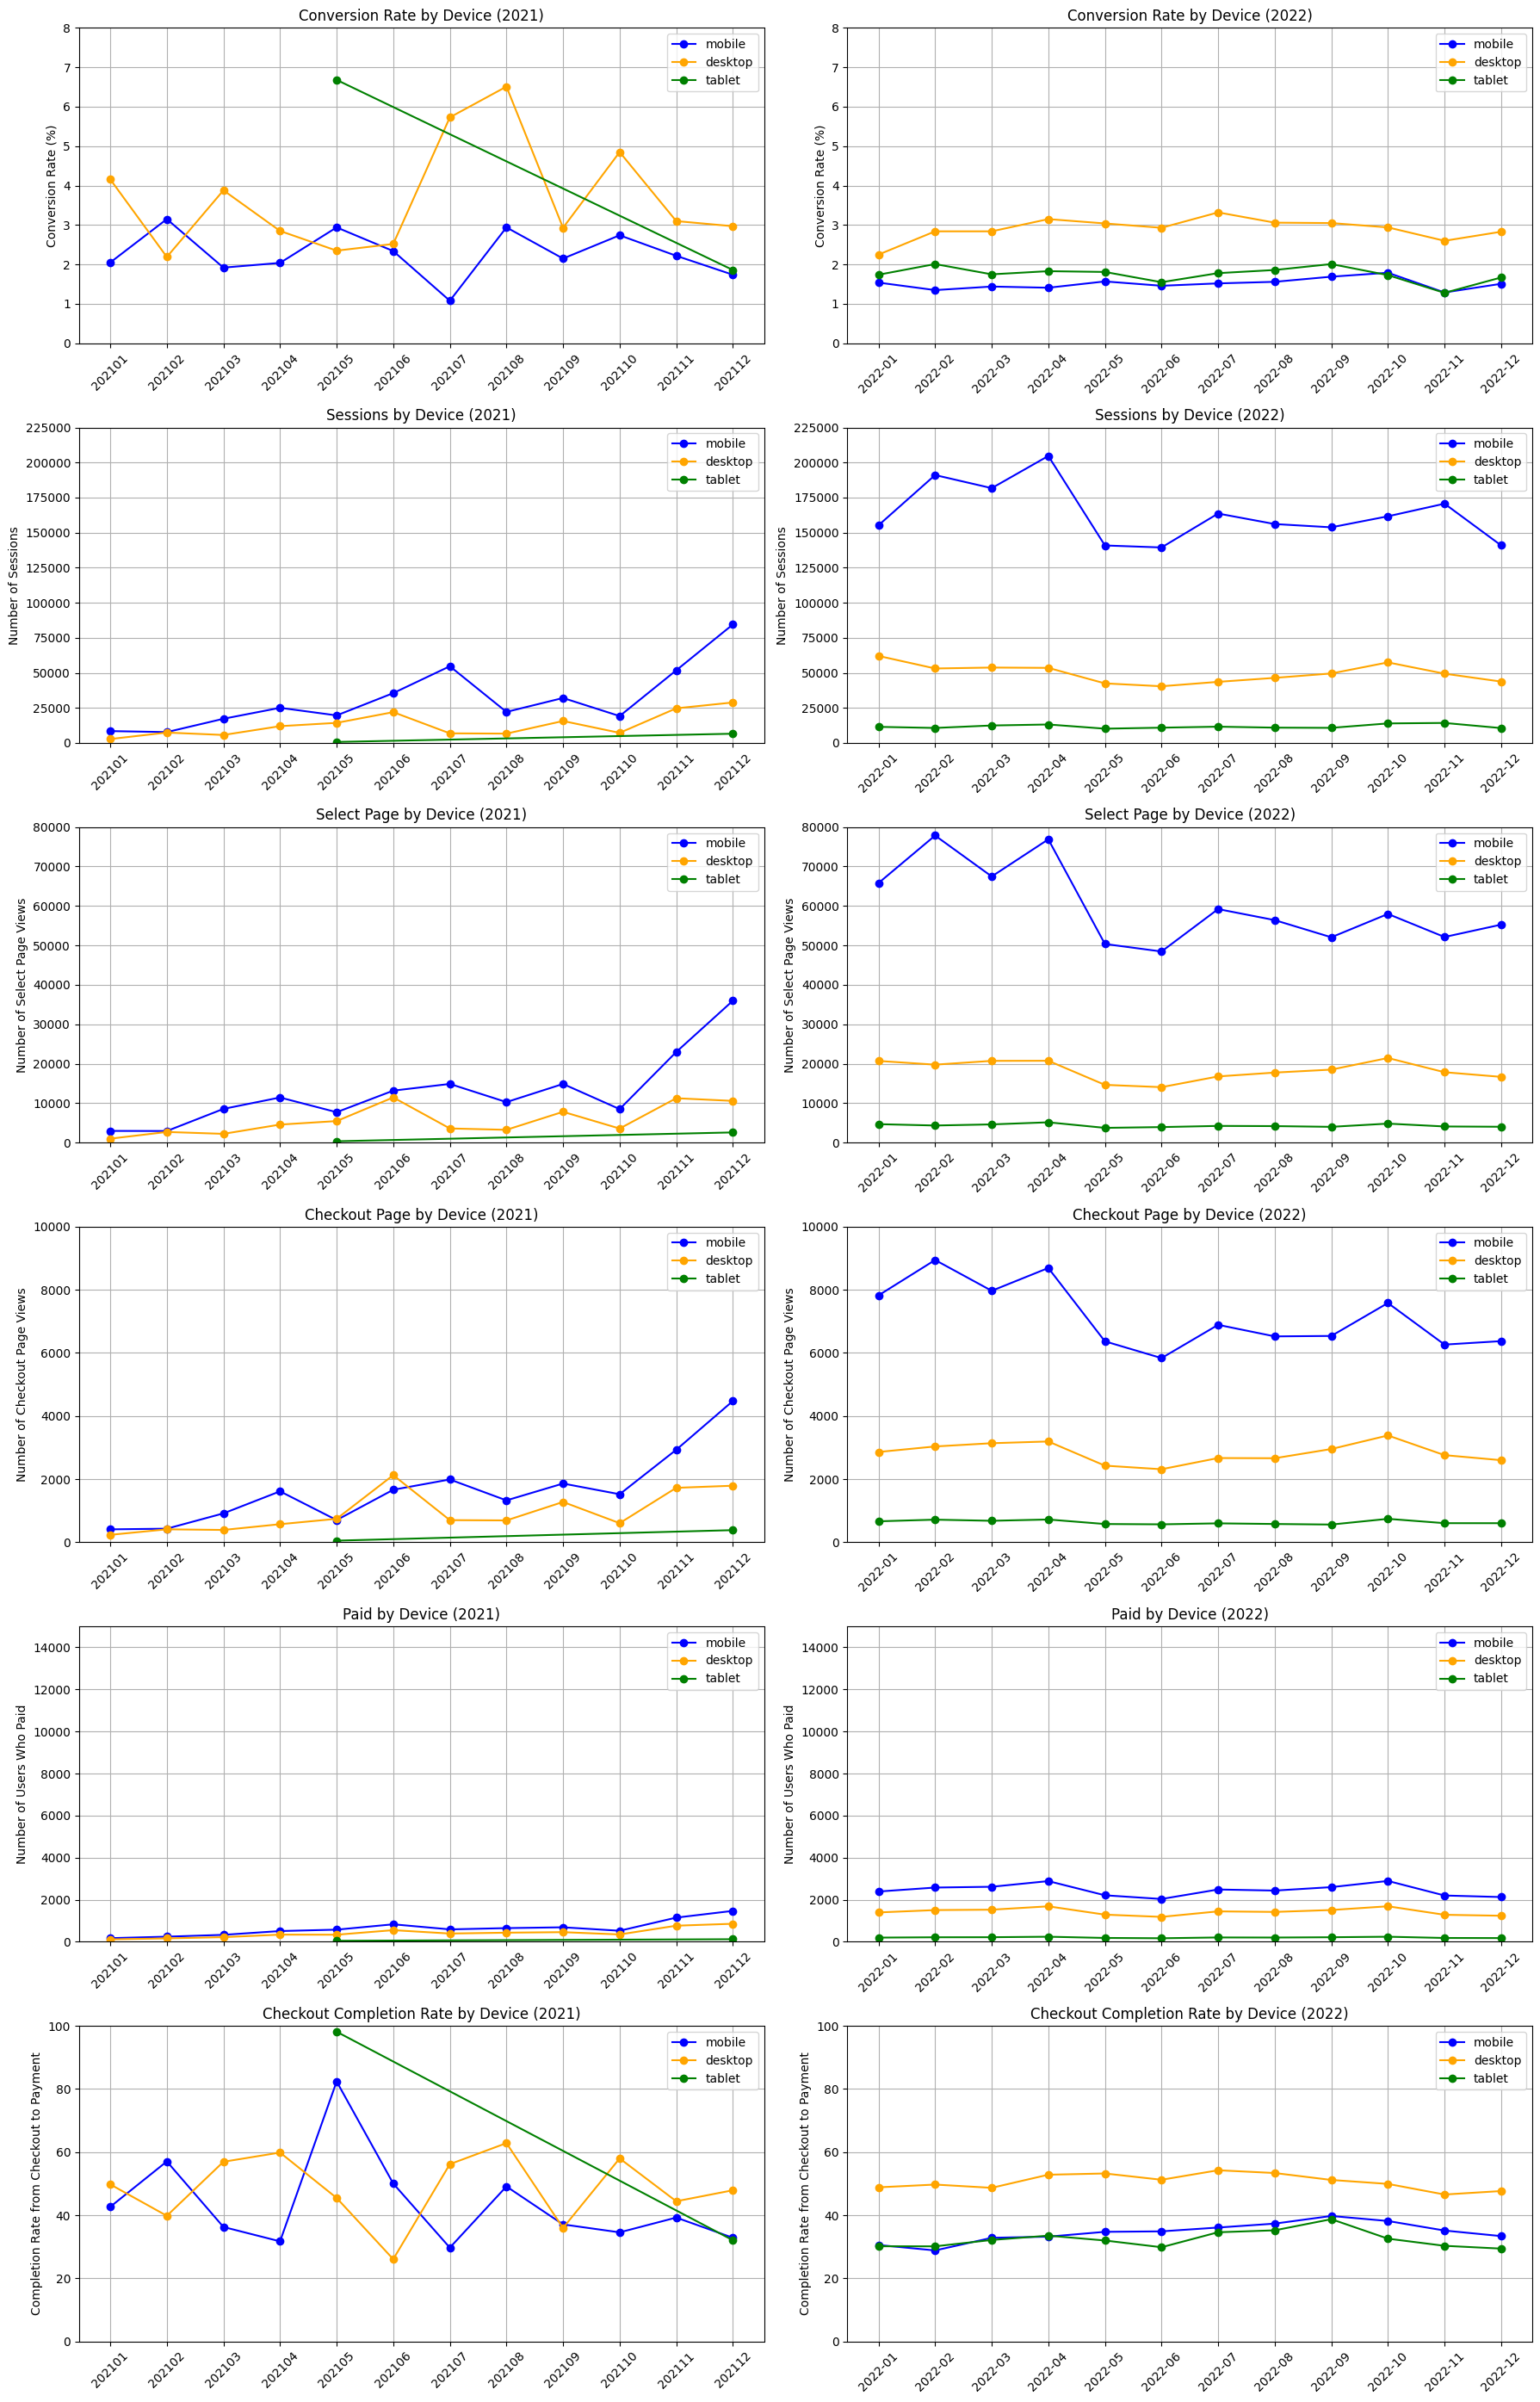

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to clean and prepare data
def load_and_prepare(file_path):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # Keep only desired device types
    allowed_devices = ['mobile', 'desktop', 'tablet']
    df = df[df['Device'].isin(allowed_devices)]

    # Clean metrics
    df['Conversion Rate'] = df['Conversion Rate'].str.rstrip('%').astype(float)

    for col in ['Sessions', 'Select Page', 'Checkout Page']:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
        df[col] = df[col].fillna(0).astype(int)

    # Add derived metrics
    df['Paid'] = df['Sessions'] * df['Conversion Rate'] / 100

    # Prevent divide-by-zero
    df['Checkout Completion Rate'] = df['Paid'] / df['Checkout Page'].replace(0, pd.NA) * 100
    df['Checkout Completion Rate'] = df['Checkout Completion Rate'].fillna(0)

    df['Month'] = df['Month'].astype(str)
    df = df.sort_values('Month')
    return df

# Load datasets
df_2021 = load_and_prepare('SessionData1.csv')
df_2022 = load_and_prepare('SessionData2.csv')

# Colors
device_colors = {
    'mobile': 'blue',
    'desktop': 'orange',
    'tablet': 'green'
}

# 6 rows x 2 columns
fig, axes = plt.subplots(6, 2, figsize=(18, 28), sharex=False)

# Metrics config
plot_config = [
    ("Conversion Rate", "Conversion Rate (%)", (0, 8)),
    ("Sessions", "Number of Sessions", (0, 225000)),
    ("Select Page", "Number of Select Page Views", (0, 80000)),
    ("Checkout Page", "Number of Checkout Page Views", (0, 10000)),
    ("Paid", "Number of Users Who Paid", (0, 15000)),
    ("Checkout Completion Rate", "Completion Rate from Checkout to Payment", (0, 100)),
]

# Plot
for i, (col, ylabel, ylim) in enumerate(plot_config):
    for j, df in enumerate([df_2021, df_2022]):
        ax = axes[i][j]
        for device in device_colors:
            device_data = df[df['Device'] == device]
            ax.plot(device_data['Month'], device_data[col], marker='o',
                    label=device, color=device_colors[device])

        year = "2021" if j == 0 else "2022"
        ax.set_title(f"{col} by Device ({year})")
        ax.set_ylabel(ylabel)
        if ylim[0] is not None or ylim[1] is not None:
            ax.set_ylim(ylim)
        ax.legend()
        ax.grid(True)
        ax.tick_params(axis='x', rotation=45)

# Layout
plt.tight_layout()
plt.show()


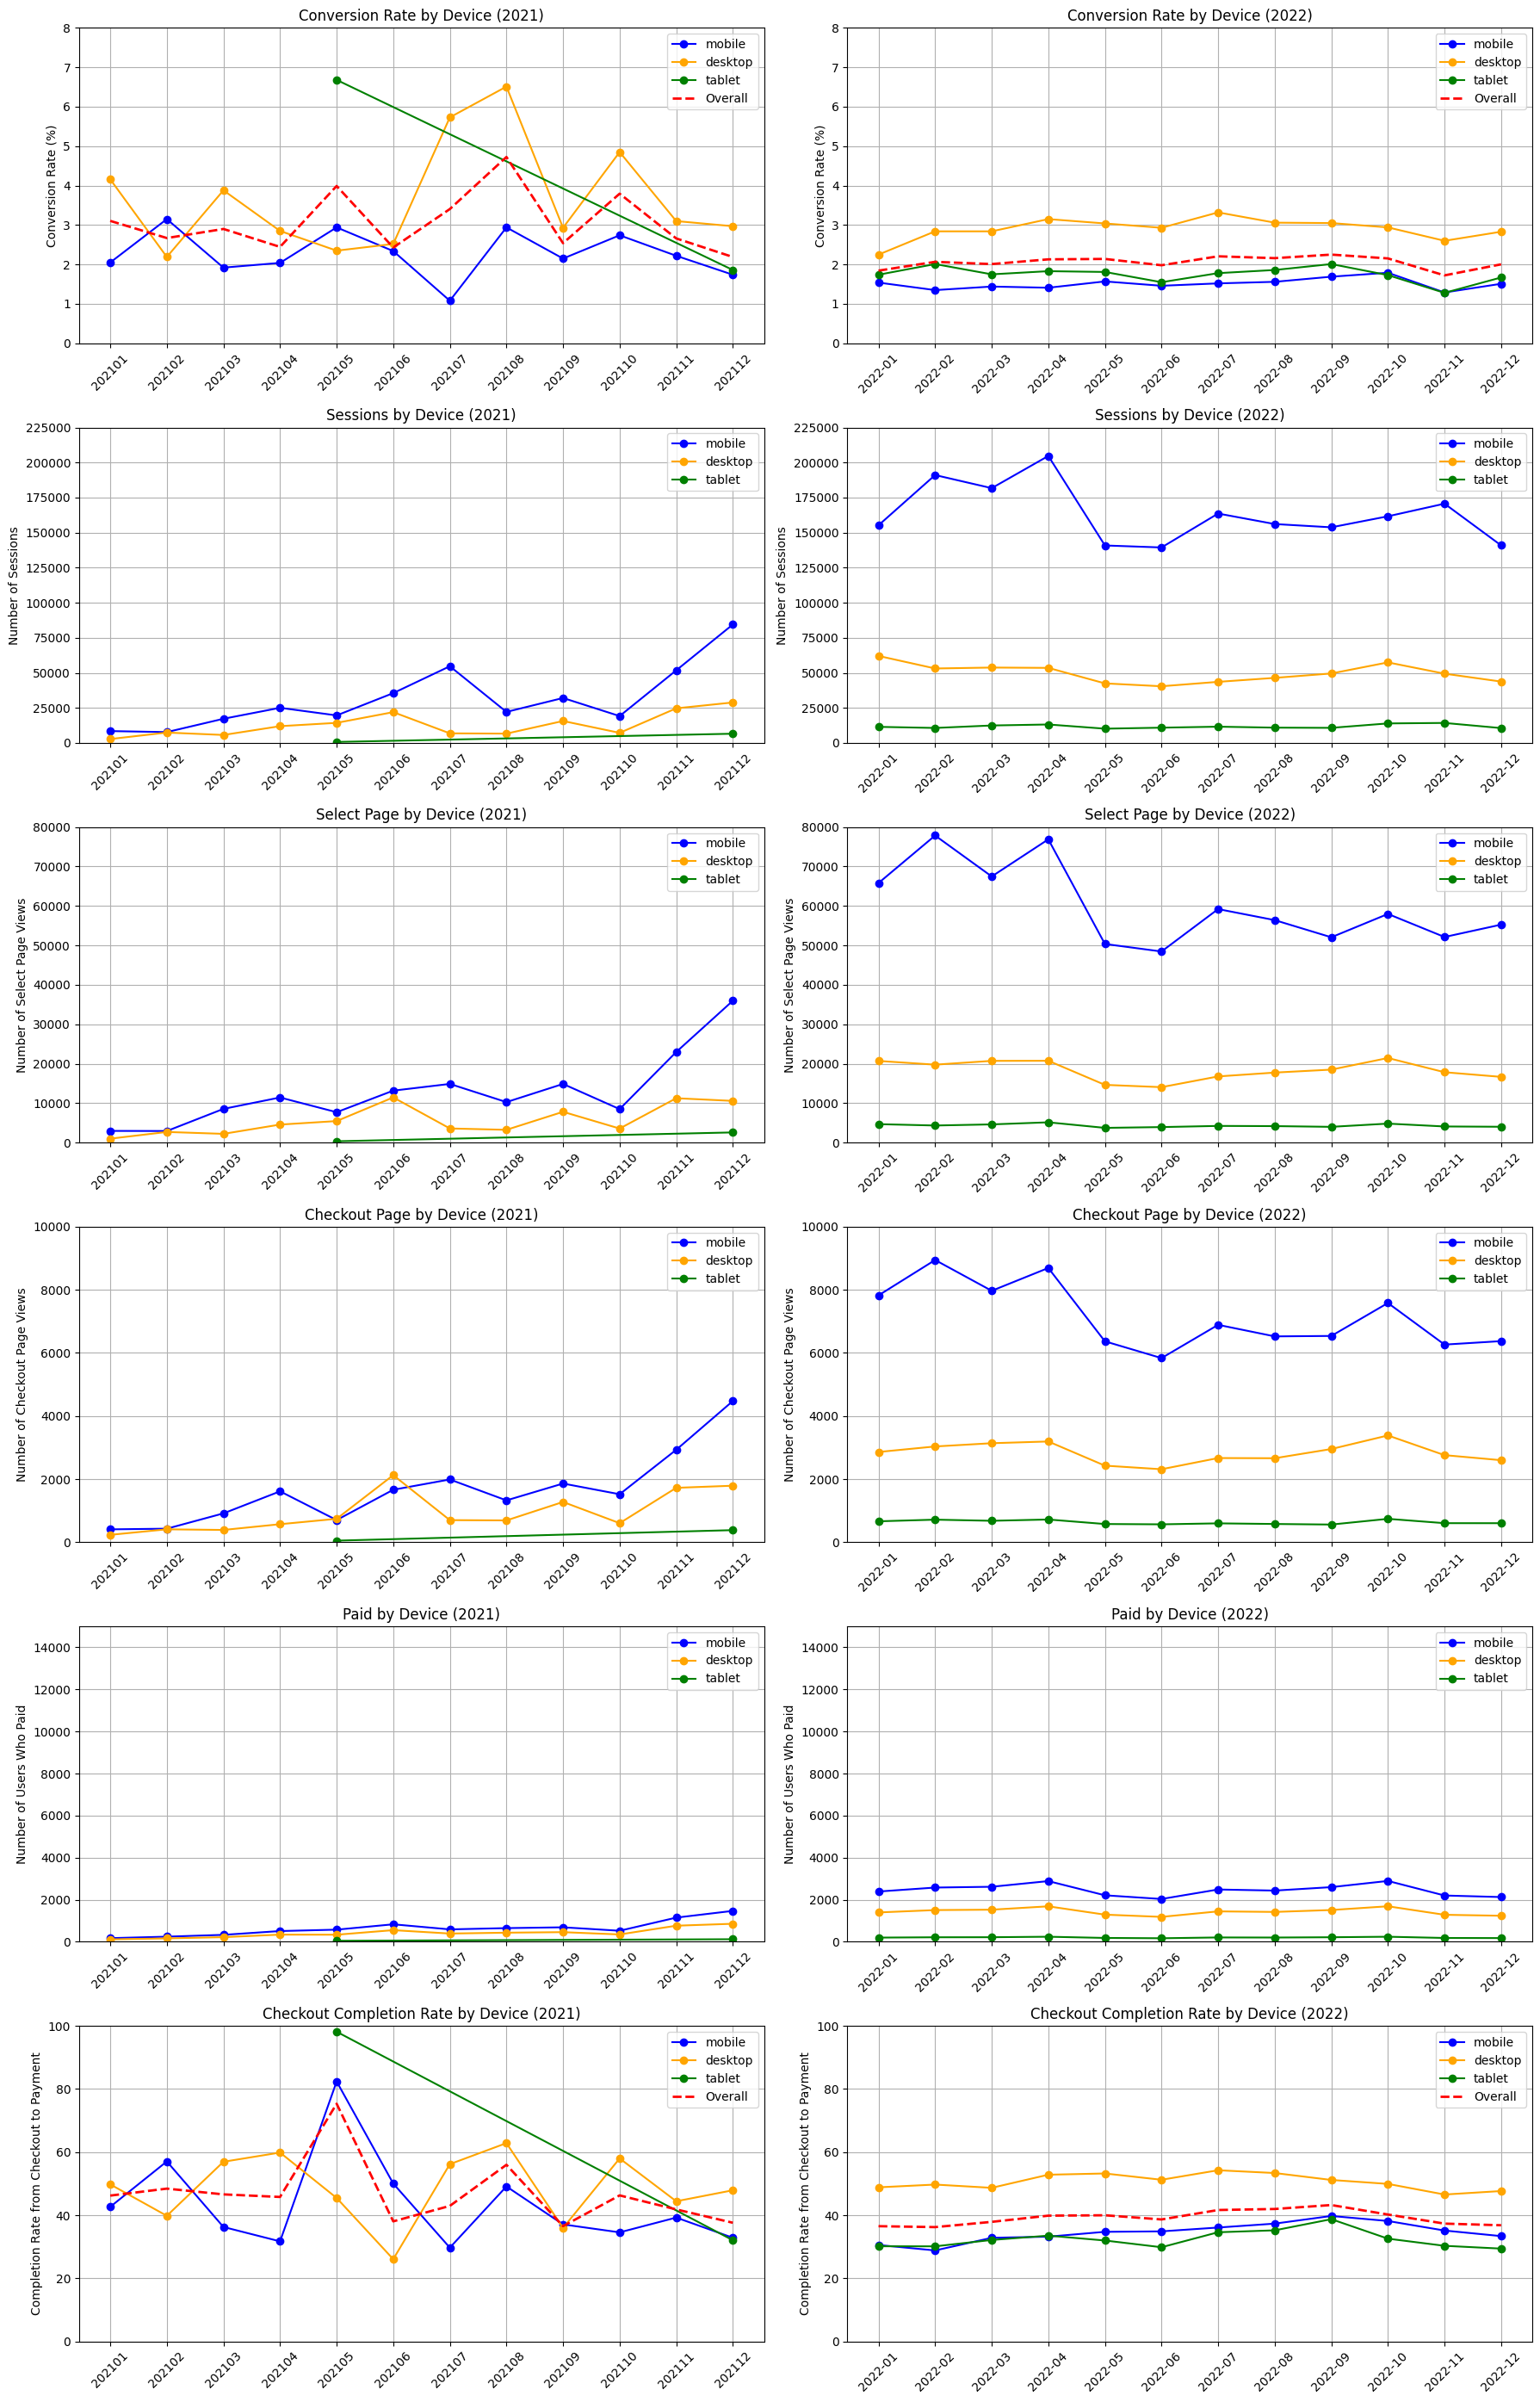

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('future.no_silent_downcasting', True)
# Function to clean and prepare data
def load_and_prepare(file_path):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=['Month'])

    # Clean metrics
    df['Conversion Rate'] = df['Conversion Rate'].str.rstrip('%').astype(float)

    for col in ['Sessions', 'Select Page', 'Checkout Page']:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
        df[col] = df[col].fillna(0).astype(int)

    # Derived metrics
    df['Paid'] = df['Sessions'] * df['Conversion Rate'] / 100
    df['Checkout Completion Rate'] = df['Paid'] / df['Checkout Page'].replace(0, pd.NA) * 100
    df['Checkout Completion Rate'] = df['Checkout Completion Rate'].fillna(0).infer_objects()


    df['Month'] = df['Month'].astype(str)
    df = df.dropna(subset=['Month'])  # Drop any rows with missing Month
    df = df.sort_values('Month')
    return df

# Load datasets
df_2021 = load_and_prepare('SessionData1.csv')
df_2022 = load_and_prepare('SessionData2.csv')

# Device colors
device_colors = {
    'mobile': 'blue',
    'desktop': 'orange',
    'tablet': 'green'
}

# Subplot grid: 6 rows x 2 columns
fig, axes = plt.subplots(6, 2, figsize=(18, 28), sharex=False)

# Metric configs
plot_config = [
    ("Conversion Rate", "Conversion Rate (%)", (0, 8)),
    ("Sessions", "Number of Sessions", (0, 225000)),
    ("Select Page", "Number of Select Page Views", (0, 80000)),
    ("Checkout Page", "Number of Checkout Page Views", (0, 10000)),
    ("Paid", "Number of Users Who Paid", (0, 15000)),
    ("Checkout Completion Rate", "Completion Rate from Checkout to Payment", (0, 100)),
]

# Metrics to apply red baseline line
metrics_with_baseline = {"Conversion Rate", "Checkout Completion Rate"}

# Plot function
def plot_metric(ax, df, col, ylabel, ylim, year):
    # Plot each device type
    for device in device_colors:
        device_data = df[df['Device'] == device]
        ax.plot(device_data['Month'], device_data[col], marker='o',
                label=device, color=device_colors[device])
    
    # If this metric needs a baseline line
    if col in metrics_with_baseline:
        overall_data = df[df['Month'].notna()].groupby('Month')[col].mean().reset_index()
        overall_data = overall_data.sort_values('Month')
        ax.plot(overall_data['Month'], overall_data[col],
                linestyle='--', color='red', linewidth=2, label='Overall')


    # Styling
    ax.set_title(f"{col} by Device ({year})")
    ax.set_ylabel(ylabel)
    if ylim[0] is not None or ylim[1] is not None:
        ax.set_ylim(ylim)
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# Loop through rows and plot
for i, (col, ylabel, ylim) in enumerate(plot_config):
    plot_metric(axes[i][0], df_2021, col, ylabel, ylim, "2021")
    plot_metric(axes[i][1], df_2022, col, ylabel, ylim, "2022")

# Finalize layout
plt.tight_layout()
plt.show()
